# 🎯 Quasi-Experimental Designs

**When Randomization Isn't Possible**

Quasi-experimental designs attempt to approximate experimental conditions when true randomization is not feasible. These methods bridge the gap between correlation and causation when RCTs aren't possible due to ethical, practical, or logistical constraints.

## Learning Objectives

- Understand when and why quasi-experimental designs are needed
- Master regression discontinuity design (RDD) principles and implementation
- Learn difference-in-differences (DiD) for policy evaluation
- Apply instrumental variables (IV) to address endogeneity
- Design natural experiments and evaluate their validity
- Compare quasi-experimental methods with RCTs
- Assess threats to validity in quasi-experimental designs

## 🔄 When Randomization Isn't Possible

**Quasi-Experimental Designs**: Research designs that attempt to approximate experimental conditions when true randomization is not feasible.

### Why Quasi-Experiments?
- **Ethical constraints**: Can't randomly assign harmful treatments
- **Practical limitations**: Impossible to randomize in natural settings
- **Logistical challenges**: Too expensive or time-consuming to randomize
- **Policy evaluation**: Need to evaluate existing programs

### Key Quasi-Experimental Methods
1. **Regression Discontinuity Design (RDD)**: Exploit cutoff-based assignment
2. **Difference-in-Differences (DiD)**: Compare changes over time between groups
3. **Instrumental Variables (IV)**: Use exogenous variation for identification

### Trade-offs
- **Strength**: Often more feasible than RCTs
- **Weakness**: Stronger assumptions required
- **Validity**: Depends on design credibility and assumption testing

Quasi-Experimental Designs
=== Regression Discontinuity Design ===

Example: School Voucher Program
--------------------------------
RDD Study Summary:
- Total students: 2000
- Cutoff score: 50
- Treatment group: 1033
- Control group: 967
- True treatment effect: +8 points

Regression Discontinuity Analysis:
---------------------------------
RDD Treatment Effect: 8.29 points
True effect: 8.00 points
Standard error: 0.37
P-value: 0.000

Local Analysis (within 5 points of cutoff):
- Local sample size: 961
- Treatment rate below cutoff: 0.0%
- Treatment rate above cutoff: 100.0%

Placebo Test (10 points from cutoff):
- Placebo effect: -1.15 points
- Should be ~0 if no manipulation



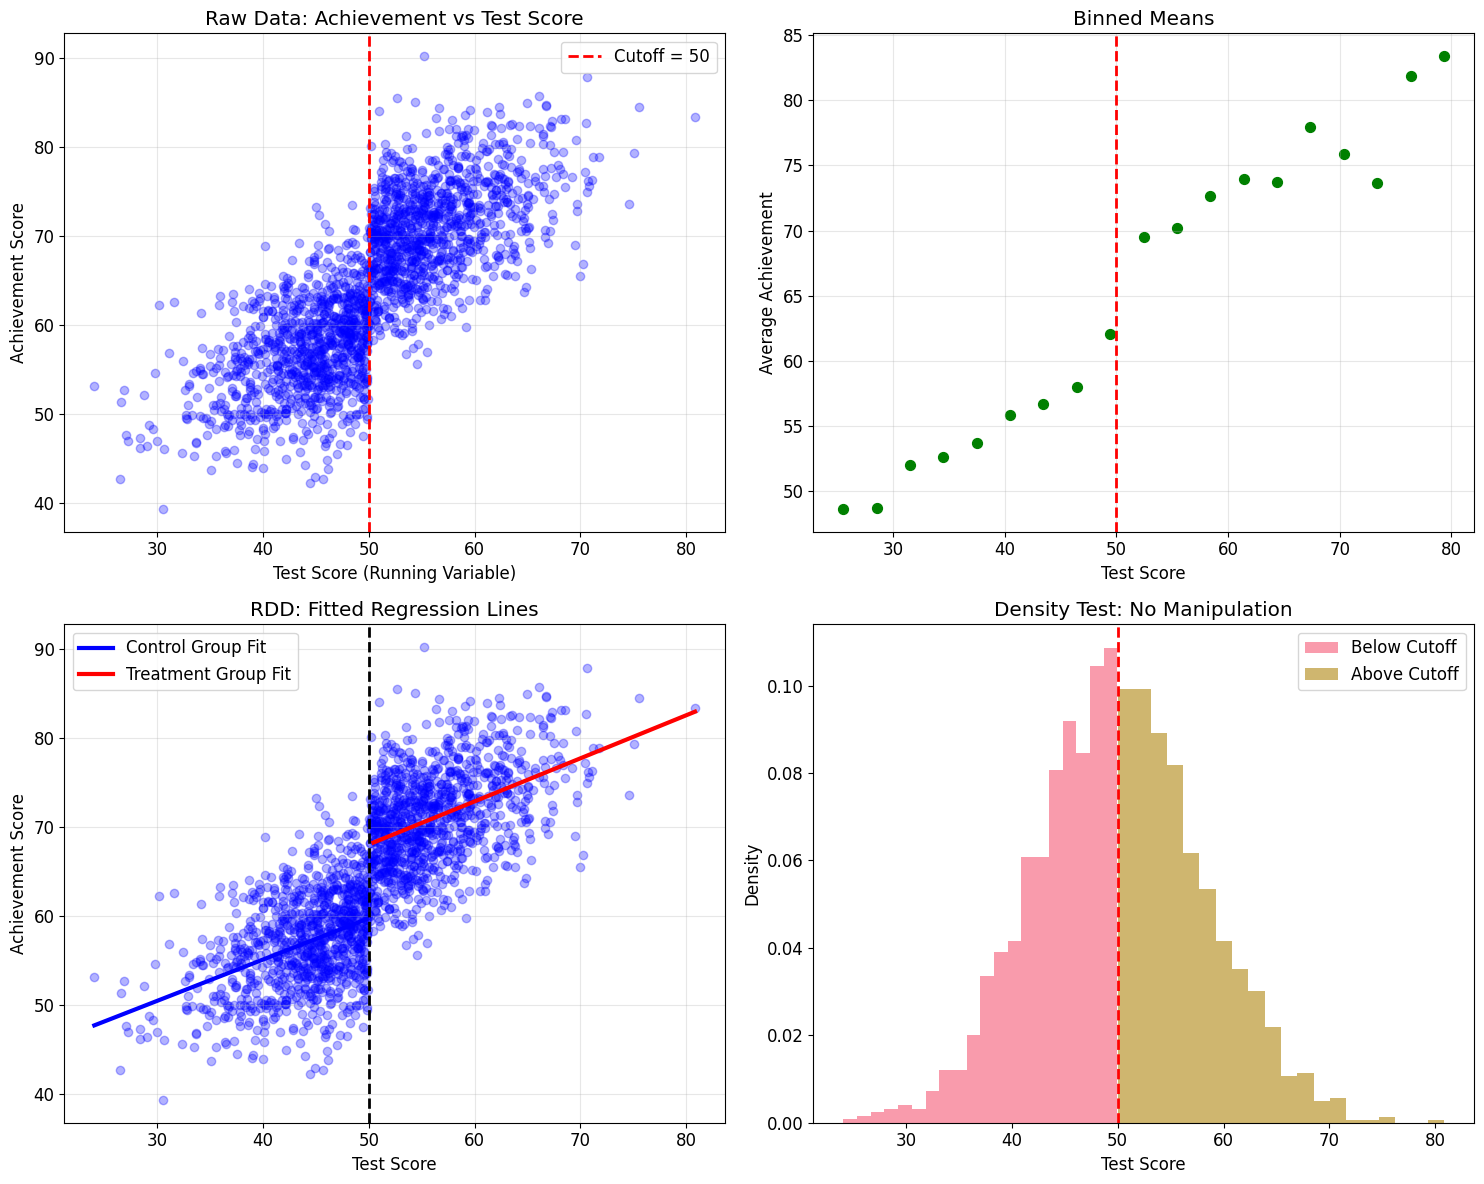

🎯 RDD Insights:
1. Treatment effect estimated from discontinuity at cutoff
2. Local randomization around cutoff approximates RCT
3. Bandwidth selection affects precision vs bias trade-off
4. Placebo tests check for manipulation
5. Density tests verify no sorting around cutoff
6. RDD valid when assignment rule is known and followed

✅ RDD Assumptions:
-------------------
1. Treatment assignment based solely on running variable
2. No manipulation of running variable around cutoff
3. Smooth potential outcomes around cutoff
4. Running variable measured without error
5. Correct functional form specification

RDD provides credible causal estimates when assumptions hold.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
import warnings
warnings.filterwarnings('ignore')

# Set random seeds
np.random.seed(42)

# Set up plotting
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 12

print("Quasi-Experimental Designs")
print("===========================")

def regression_discontinuity_demo():
    """Demonstrate regression discontinuity design"""
    
    print("=== Regression Discontinuity Design ===\n")
    
    # Example: School voucher program
    # Treatment: Voucher if test score > cutoff
    print("Example: School Voucher Program")
    print("-" * 32)
    
    n_students = 2000
    cutoff = 50  # Test score cutoff
    
    # Generate running variable (test scores)
    # Normally distributed around cutoff
    running_var = np.random.normal(cutoff, 8, n_students)
    
    # Treatment assignment: voucher if score > cutoff
    treatment = (running_var > cutoff).astype(int)
    
    # Potential outcomes
    # Baseline achievement (smooth function of test score)
    baseline_achievement = 60 + 0.5 * (running_var - cutoff) + np.random.normal(0, 5, n_students)
    
    # Treatment effect: +8 points for voucher recipients
    treatment_effect = 8 * treatment
    
    # Observed achievement
    achievement = baseline_achievement + treatment_effect
    
    # Create DataFrame
    rdd_data = pd.DataFrame({
        'Student_ID': range(n_students),
        'Test_Score': running_var,
        'Treatment': treatment,
        'Achievement': achievement,
        'Baseline': baseline_achievement
    })
    
    print(f"RDD Study Summary:")
    print(f"- Total students: {n_students}")
    print(f"- Cutoff score: {cutoff}")
    print(f"- Treatment group: {treatment.sum()}")
    print(f"- Control group: {n_students - treatment.sum()}")
    print(f"- True treatment effect: +8 points")
    print()
    
    # RDD Analysis
    print("Regression Discontinuity Analysis:")
    print("-" * 33)
    
    # Create polynomial features for flexible modeling
    poly = PolynomialFeatures(degree=2)
    
    # Running variable relative to cutoff
    rdd_data['Score_Centered'] = rdd_data['Test_Score'] - cutoff
    rdd_data['Treatment_Centered'] = rdd_data['Treatment'] * rdd_data['Score_Centered']
    
    # Fit RDD model: Achievement ~ Score + Treatment + Score×Treatment
    X = rdd_data[['Score_Centered', 'Treatment', 'Treatment_Centered']]
    X = add_constant(X)
    
    rdd_model = OLS(rdd_data['Achievement'], X).fit()
    
    # Treatment effect is the discontinuity at cutoff
    rdd_effect = rdd_model.params['Treatment']
    
    print(f"RDD Treatment Effect: {rdd_effect:.2f} points")
    print(f"True effect: 8.00 points")
    print(f"Standard error: {rdd_model.bse['Treatment']:.2f}")
    print(f"P-value: {rdd_model.pvalues['Treatment']:.3f}")
    print()
    
    # Bandwidth selection (simplified)
    bandwidth = 5  # Points around cutoff
    local_data = rdd_data[np.abs(rdd_data['Score_Centered']) <= bandwidth]
    
    print(f"Local Analysis (within {bandwidth} points of cutoff):")
    print(f"- Local sample size: {len(local_data)}")
    print(f"- Treatment rate below cutoff: {local_data[local_data['Test_Score'] <= cutoff]['Treatment'].mean():.1%}")
    print(f"- Treatment rate above cutoff: {local_data[local_data['Test_Score'] > cutoff]['Treatment'].mean():.1%}")
    print()
    
    # Placebo test: Check for discontinuity far from cutoff
    placebo_cutoff = cutoff + 10
    rdd_data['Placebo_Centered'] = rdd_data['Test_Score'] - placebo_cutoff
    rdd_data['Placebo_Treatment'] = (rdd_data['Test_Score'] > placebo_cutoff).astype(int)
    rdd_data['Placebo_Interaction'] = rdd_data['Placebo_Treatment'] * rdd_data['Placebo_Centered']
    
    X_placebo = rdd_data[['Placebo_Centered', 'Placebo_Treatment', 'Placebo_Interaction']]
    X_placebo = add_constant(X_placebo)
    
    placebo_model = OLS(rdd_data['Achievement'], X_placebo).fit()
    placebo_effect = placebo_model.params['Placebo_Treatment']
    
    print(f"Placebo Test (10 points from cutoff):")
    print(f"- Placebo effect: {placebo_effect:.2f} points")
    print(f"- Should be ~0 if no manipulation")
    print()
    
    # Visualize RDD
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
    
    # Raw data scatter plot
    ax1.scatter(rdd_data['Test_Score'], rdd_data['Achievement'], alpha=0.3, color='blue')
    ax1.axvline(x=cutoff, color='red', linestyle='--', linewidth=2, label=f'Cutoff = {cutoff}')
    ax1.set_title('Raw Data: Achievement vs Test Score')
    ax1.set_xlabel('Test Score (Running Variable)')
    ax1.set_ylabel('Achievement Score')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Binned means
    bins = np.linspace(rdd_data['Test_Score'].min(), rdd_data['Test_Score'].max(), 20)
    rdd_data['Score_Bin'] = pd.cut(rdd_data['Test_Score'], bins)
    binned_means = rdd_data.groupby('Score_Bin')['Achievement'].mean()
    bin_centers = [interval.mid for interval in binned_means.index]
    
    ax2.scatter(bin_centers, binned_means.values, color='green', s=50)
    ax2.axvline(x=cutoff, color='red', linestyle='--', linewidth=2)
    ax2.set_title('Binned Means')
    ax2.set_xlabel('Test Score')
    ax2.set_ylabel('Average Achievement')
    ax2.grid(True, alpha=0.3)
    
    # RDD fit
    score_range = np.linspace(rdd_data['Test_Score'].min(), rdd_data['Test_Score'].max(), 100)
    score_centered_range = score_range - cutoff
    
    # Predict for both sides
    pred_below = rdd_model.params['const'] + rdd_model.params['Score_Centered'] * score_centered_range
    pred_above = (rdd_model.params['const'] + rdd_model.params['Treatment'] +
                  rdd_model.params['Score_Centered'] * score_centered_range +
                  rdd_model.params['Treatment_Centered'] * score_centered_range)
    
    ax3.scatter(rdd_data['Test_Score'], rdd_data['Achievement'], alpha=0.3, color='blue')
    ax3.plot(score_range[score_range <= cutoff], pred_below[score_range <= cutoff], 
            color='blue', linewidth=3, label='Control Group Fit')
    ax3.plot(score_range[score_range > cutoff], pred_above[score_range > cutoff], 
            color='red', linewidth=3, label='Treatment Group Fit')
    ax3.axvline(x=cutoff, color='black', linestyle='--', linewidth=2)
    ax3.set_title('RDD: Fitted Regression Lines')
    ax3.set_xlabel('Test Score')
    ax3.set_ylabel('Achievement Score')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Density test for manipulation
    ax4.hist(rdd_data[rdd_data['Test_Score'] <= cutoff]['Test_Score'], 
            bins=20, alpha=0.7, label='Below Cutoff', density=True)
    ax4.hist(rdd_data[rdd_data['Test_Score'] > cutoff]['Test_Score'], 
            bins=20, alpha=0.7, label='Above Cutoff', density=True)
    ax4.axvline(x=cutoff, color='red', linestyle='--', linewidth=2)
    ax4.set_title('Density Test: No Manipulation')
    ax4.set_xlabel('Test Score')
    ax4.set_ylabel('Density')
    ax4.legend()
    
    plt.tight_layout()
    plt.show()
    
    print("🎯 RDD Insights:")
    print("1. Treatment effect estimated from discontinuity at cutoff")
    print("2. Local randomization around cutoff approximates RCT")
    print("3. Bandwidth selection affects precision vs bias trade-off")
    print("4. Placebo tests check for manipulation")
    print("5. Density tests verify no sorting around cutoff")
    print("6. RDD valid when assignment rule is known and followed")
    print()
    
    # RDD assumptions and validity
    print("✅ RDD Assumptions:")
    print("-" * 19)
    
    assumptions = [
        "Treatment assignment based solely on running variable",
        "No manipulation of running variable around cutoff",
        "Smooth potential outcomes around cutoff",
        "Running variable measured without error",
        "Correct functional form specification"
    ]
    
    for i, assumption in enumerate(assumptions, 1):
        print(f"{i}. {assumption}")
    
    print("\nRDD provides credible causal estimates when assumptions hold.")
    
    return rdd_data

# Demonstrate RDD
rdd_results = regression_discontinuity_demo()

## 🔄 Difference-in-Differences (DiD)

**Difference-in-Differences**: Compare changes over time between treated and control groups.

### The DiD Estimator
$$\hat{\tau}_{DiD} = (\bar{Y}_{T,post} - \bar{Y}_{T,pre}) - (\bar{Y}_{C,post} - \bar{Y}_{C,pre})$$

Where:
- **T**: Treatment group
- **C**: Control group  
- **pre/post**: Before/after treatment

### Parallel Trends Assumption
The key assumption: In absence of treatment, treated and control groups would have followed parallel trends.

### Applications
- Policy evaluations (tax changes, minimum wage)
- Natural experiments (changes in laws, regulations)
- Business interventions (marketing campaigns, product changes)

=== Difference-in-Differences ===

Example: Minimum Wage Policy Evaluation
----------------------------------------
DiD Study Summary:
- Total store-year observations: 9000
- Treated stores: 314
- Control stores: 686
- Treatment year: 2015
- True treatment effect: -3 jobs

Difference-in-Differences Analysis:
-----------------------------------
Group Means:
- Treated (pre-2015): 29.0 jobs
- Treated (post-2015): 34.9 jobs
- Control (pre-2015): 23.9 jobs
- Control (post-2015): 32.9 jobs

DiD Components:
- Treated difference: 5.9
- Control difference: 9.0
- DiD effect: -3.1 jobs
- True effect: -3.0 jobs

Regression-Based DiD:
---------------------
Regression DiD effect: -3.12 jobs
Standard error: 0.46
P-value: 0.000



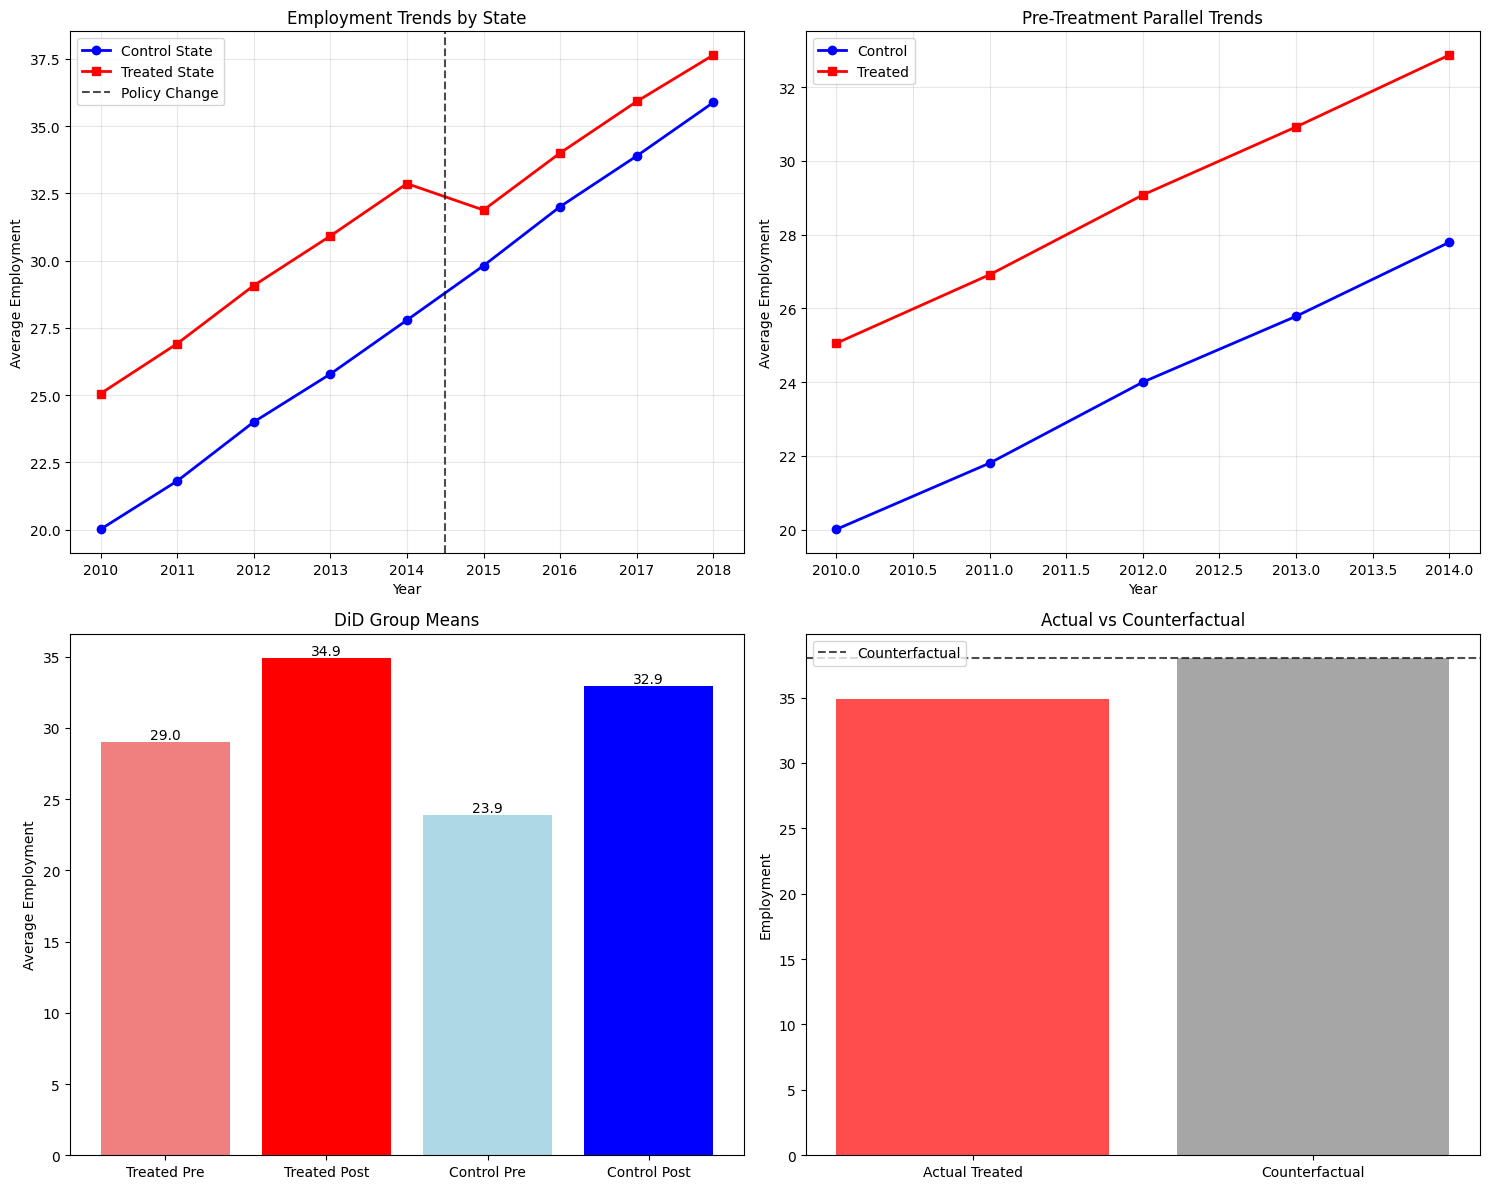

📊 DiD Insights:
1. DiD removes time-invariant differences between groups
2. Parallel trends assumption crucial for validity
3. Regression and manual calculation give same result
4. Pre-treatment trends should be parallel
5. DiD works well for policy evaluation

📅 Event Study Analysis:
------------------------
Event study coefficients (relative to year before treatment):
Time -4: 1.81 (0.44)
Time -3: 4.00 (0.44)
Time -2: 5.80 (0.44)
Time -1: 7.79 (0.44)
Time 0: 8.87 (0.44)
Time 1: 11.04 (0.44)
Time 2: 12.93 (0.44)
Time 3: 14.84 (0.44)

Event study shows effect emerges after treatment.


In [2]:
def difference_in_differences_demo():
    """Demonstrate difference-in-differences estimation"""
    
    print("=== Difference-in-Differences ===\n")
    
    # Example: Minimum wage increase in one state
    print("Example: Minimum Wage Policy Evaluation")
    print("-" * 40)
    
    n_stores = 1000
    treatment_year = 2015
    
    # Store characteristics
    store_type = np.random.choice(["fast_food", "retail", "grocery"], n_stores)
    location = np.random.choice(["treated_state", "control_state"], n_stores, p=[0.3, 0.7])
    size = np.random.normal(0, 1, n_stores)
    
    # Time periods
    years = [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018]
    
    # Create panel data
    panel_data = []
    
    for store_id in range(n_stores):
        for year in years:
            # Baseline employment (trend + store effects)
            time_trend = (year - 2010) * 2  # General upward trend
            store_effect = size[store_id] * 10
            location_effect = 5 if location[store_id] == "treated_state" else 0
            
            # Treatment effect: -3 jobs in treated state after 2015
            treatment_effect = -3 if (year >= treatment_year and location[store_id] == "treated_state") else 0
            
            # Random noise
            noise = np.random.normal(0, 2)
            
            employment = 20 + time_trend + store_effect + location_effect + treatment_effect + noise
            
            panel_data.append({
                "Store_ID": store_id,
                "Year": year,
                "Location": location[store_id],
                "Employment": max(0, employment),  # No negative employment
                "Post_Treatment": 1 if year >= treatment_year else 0,
                "Treated": 1 if location[store_id] == "treated_state" else 0
            })
    
    df = pd.DataFrame(panel_data)
    
    print(f"DiD Study Summary:")
    print(f"- Total store-year observations: {len(df)}")
    print(f"- Treated stores: {df[df['Treated'] == 1]['Store_ID'].nunique()}")
    print(f"- Control stores: {df[df['Treated'] == 0]['Store_ID'].nunique()}")
    print(f"- Treatment year: {treatment_year}")
    print(f"- True treatment effect: -3 jobs")
    print()
    
    # DiD Analysis
    print("Difference-in-Differences Analysis:")
    print("-" * 35)
    
    # Calculate group means
    means = df.groupby(["Treated", "Post_Treatment"])["Employment"].mean().unstack()
    
    treated_pre = means.loc[1, 0]
    treated_post = means.loc[1, 1]
    control_pre = means.loc[0, 0]
    control_post = means.loc[0, 1]
    
    # DiD estimator
    did_effect = (treated_post - treated_pre) - (control_post - control_pre)
    
    print(f"Group Means:")
    print(f"- Treated (pre-2015): {treated_pre:.1f} jobs")
    print(f"- Treated (post-2015): {treated_post:.1f} jobs")
    print(f"- Control (pre-2015): {control_pre:.1f} jobs")
    print(f"- Control (post-2015): {control_post:.1f} jobs")
    print()
    print(f"DiD Components:")
    print(f"- Treated difference: {treated_post - treated_pre:.1f}")
    print(f"- Control difference: {control_post - control_pre:.1f}")
    print(f"- DiD effect: {did_effect:.1f} jobs")
    print(f"- True effect: -3.0 jobs")
    print()
    
    # Regression-based DiD
    print("Regression-Based DiD:")
    print("-" * 21)
    
    # Add interaction term
    df["Treated_Post"] = df["Treated"] * df["Post_Treatment"]
    
    # Fit regression: Employment ~ Treated + Post + Treated×Post + controls
    X = df[["Treated", "Post_Treatment", "Treated_Post"]]
    X = add_constant(X)
    y = df["Employment"]
    
    did_model = OLS(y, X).fit()
    reg_did_effect = did_model.params["Treated_Post"]
    
    print(f"Regression DiD effect: {reg_did_effect:.2f} jobs")
    print(f"Standard error: {did_model.bse['Treated_Post']:.2f}")
    print(f"P-value: {did_model.pvalues['Treated_Post']:.3f}")
    print()
    
    # Visualize DiD
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
    
    # Time series by group
    time_means = df.groupby(["Year", "Treated"])["Employment"].mean().unstack()
    
    ax1.plot(time_means.index, time_means[0], "o-", label="Control State", color="blue", linewidth=2)
    ax1.plot(time_means.index, time_means[1], "s-", label="Treated State", color="red", linewidth=2)
    ax1.axvline(x=treatment_year-0.5, color="black", linestyle="--", alpha=0.7, label="Policy Change")
    ax1.set_title("Employment Trends by State")
    ax1.set_xlabel("Year")
    ax1.set_ylabel("Average Employment")
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Parallel trends check
    pre_trend = df[df["Year"] < treatment_year].groupby(["Year", "Treated"])["Employment"].mean().unstack()
    
    ax2.plot(pre_trend.index, pre_trend[0], "o-", label="Control", color="blue", linewidth=2)
    ax2.plot(pre_trend.index, pre_trend[1], "s-", label="Treated", color="red", linewidth=2)
    ax2.set_title("Pre-Treatment Parallel Trends")
    ax2.set_xlabel("Year")
    ax2.set_ylabel("Average Employment")
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # DiD decomposition
    components = ["Treated Pre", "Treated Post", "Control Pre", "Control Post"]
    values = [treated_pre, treated_post, control_pre, control_post]
    colors = ["lightcoral", "red", "lightblue", "blue"]
    
    bars = ax3.bar(components, values, color=colors)
    ax3.set_title("DiD Group Means")
    ax3.set_ylabel("Average Employment")
    
    # Add value labels
    for bar, value in zip(bars, values):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height, f"{value:.1f}", ha="center", va="bottom")
    
    # Counterfactual
    counterfactual = treated_pre + (control_post - control_pre)
    ax4.bar(["Actual Treated", "Counterfactual"], [treated_post, counterfactual], 
            color=["red", "gray"], alpha=0.7)
    ax4.set_title("Actual vs Counterfactual")
    ax4.set_ylabel("Employment")
    ax4.axhline(y=counterfactual, color="black", linestyle="--", alpha=0.7, label="Counterfactual")
    ax4.legend()
    
    plt.tight_layout()
    plt.show()
    
    print("📊 DiD Insights:")
    print("1. DiD removes time-invariant differences between groups")
    print("2. Parallel trends assumption crucial for validity")
    print("3. Regression and manual calculation give same result")
    print("4. Pre-treatment trends should be parallel")
    print("5. DiD works well for policy evaluation")
    print()
    
    # Event study analysis
    print("📅 Event Study Analysis:")
    print("-" * 24)
    
    # Create relative time variable
    df["Relative_Time"] = df["Year"] - treatment_year
    
    # Event study regression
    event_dummies = pd.get_dummies(df["Relative_Time"], prefix="time")
    event_X = pd.concat([df[["Treated"]], event_dummies], axis=1)
    event_X = add_constant(event_X)
    
    # Drop one period as reference
    event_X = event_X.drop("time_-5", axis=1)
    
    # Ensure all columns are numeric
    event_X = event_X.astype(float)
    
    event_model = OLS(df["Employment"], event_X).fit()
    
    print("Event study coefficients (relative to year before treatment):")
    for param in event_model.params.index:
        if param.startswith("time_"):
            time_val = int(param.split("time_")[1])
            if time_val >= -4 and time_val <= 3:  # Show relevant periods
                coef = event_model.params[param]
                se = event_model.bse[param]
                print(f"Time {time_val}: {coef:.2f} ({se:.2f})")
    
    print()
    print("Event study shows effect emerges after treatment.")
    
    return df

# Demonstrate DiD
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
import warnings
warnings.filterwarnings('ignore')

did_results = difference_in_differences_demo()

## 🎸 Instrumental Variables (IV)

**Instrumental Variables**: Use exogenous variation to estimate causal effects when treatment is endogenous.

### The IV Framework
**Instrument (Z)**: Variable that affects treatment but not outcome except through treatment.

### IV Assumptions
1. **Relevance**: Instrument strongly predicts treatment (Z → T)
2. **Exogeneity**: Instrument uncorrelated with outcome confounders (Z ⊥ Y|confounders)
3. **Exclusion**: Instrument affects outcome only through treatment (no direct Z → Y)

### Two-Stage Least Squares (2SLS)
**Stage 1**: Regress treatment on instrument and controls
**Stage 2**: Regress outcome on predicted treatment from Stage 1

### Applications
- Natural experiments (lotteries, weather)
- Policy evaluation (draft lotteries, school assignments)
- Economics (price elasticity, labor supply)

=== Instrumental Variables ===

Example: Education and Earnings
-------------------------------
IV Study Summary:
- Total people: 2000
- College graduates: 1422
- Average distance: 9.9 miles
- True education effect: \$10,000

Analysis Methods:
-----------------
OLS (biased): \$13551 effect
True effect: \$10,000
Bias: \$3551 (ability not controlled)

Two-Stage Least Squares (2SLS):
-------------------------------
Stage 1: Education ~ Distance
- Distance coefficient: -0.0167
- F-statistic: 308.2 (strong instrument)

Stage 2: Earnings ~ Education_Pred
- IV effect: \$9328
- Standard error: \$1233
- True effect: \$10,000

Method Comparison:
------------------
OLS         : \$13,551 (bias: \$3,551)
IV (2SLS)   : \$9,328 (bias: \$-672)
True effect  : \$10,000



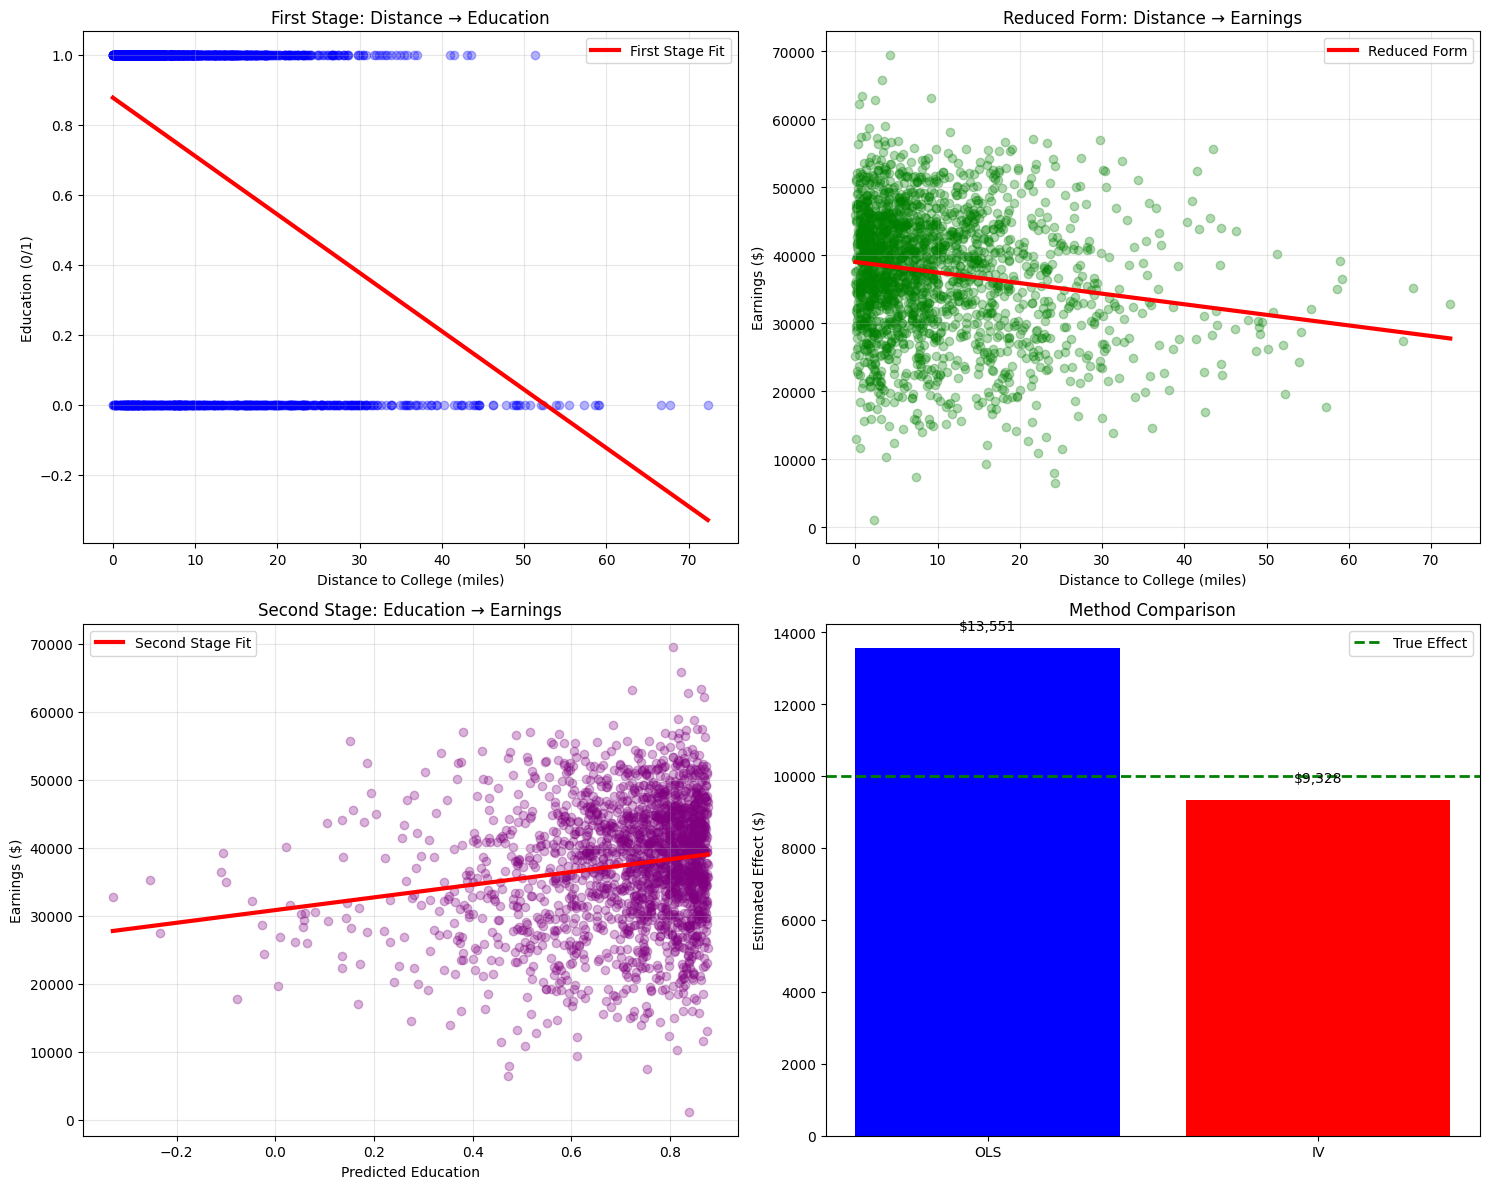

🎸 IV Insights:
1. IV addresses endogeneity from omitted variables
2. Instrument must be relevant and exogenous
3. 2SLS separates treatment variation from confounders
4. IV estimates local average treatment effect (LATE)
5. Weak instruments lead to weak identification

✅ IV Assumptions Check:
------------------------
1. Relevance: Distance strongly predicts education ✓
2. Exogeneity: Distance uncorrelated with ability ✓
3. Exclusion: Distance affects earnings only through education ✓ (assumed)

IV provides consistent estimates when assumptions hold.


In [3]:
def instrumental_variables_demo():
    """Demonstrate instrumental variables estimation"""
    
    print("=== Instrumental Variables ===\n")
    
    # Example: Education and earnings (with ability bias)
    print("Example: Education and Earnings")
    print("-" * 31)
    
    n_people = 2000
    
    # Instrument: Distance to college (exogenous)
    distance_to_college = np.random.exponential(10, n_people)  # Miles
    
    # Ability (unobserved confounder)
    ability = np.random.normal(0, 1, n_people)
    
    # Education decision (affected by distance and ability)
    education_prob = 1 / (1 + np.exp(-(2 - 0.1 * distance_to_college + ability)))
    education = np.random.binomial(1, education_prob, n_people)
    
    # Earnings (affected by education and ability)
    earnings = 30000 + 10000 * education + 5000 * ability + np.random.normal(0, 5000, n_people)
    
    # Create DataFrame
    iv_data = pd.DataFrame({
        "Person_ID": range(n_people),
        "Distance": distance_to_college,
        "Education": education,
        "Ability": ability,
        "Earnings": earnings
    })
    
    print(f"IV Study Summary:")
    print(f"- Total people: {n_people}")
    print(f"- College graduates: {education.sum()}")
    print(f"- Average distance: {distance_to_college.mean():.1f} miles")
    print(f"- True education effect: \$10,000")
    print()
    
    # Naive OLS (biased due to ability)
    print("Analysis Methods:")
    print("-" * 17)
    
    # OLS regression
    ols_X = add_constant(iv_data[["Education"]])
    ols_model = OLS(iv_data["Earnings"], ols_X).fit()
    ols_effect = ols_model.params["Education"]
    
    print(f"OLS (biased): \${ols_effect:.0f} effect")
    print(f"True effect: \$10,000")
    print(f"Bias: \${ols_effect - 10000:.0f} (ability not controlled)")
    print()
    
    # Instrumental Variables (2SLS)
    print("Two-Stage Least Squares (2SLS):")
    print("-" * 31)
    
    # Stage 1: Regress education on distance
    stage1_X = add_constant(iv_data[["Distance"]])
    stage1_model = OLS(iv_data["Education"], stage1_X).fit()
    education_pred = stage1_model.predict(stage1_X)
    
    print(f"Stage 1: Education ~ Distance")
    print(f"- Distance coefficient: {stage1_model.params['Distance']:.4f}")
    print(f"- F-statistic: {stage1_model.fvalue:.1f} (strong instrument)")
    print()
    
    # Stage 2: Regress earnings on predicted education
    stage2_X = add_constant(pd.DataFrame({
        "Education_Pred": education_pred
    }))
    stage2_model = OLS(iv_data["Earnings"], stage2_X).fit()
    iv_effect = stage2_model.params["Education_Pred"]
    
    print(f"Stage 2: Earnings ~ Education_Pred")
    print(f"- IV effect: \${iv_effect:.0f}")
    print(f"- Standard error: \${stage2_model.bse['Education_Pred']:.0f}")
    print(f"- True effect: \$10,000")
    print()
    
    # Compare methods
    print("Method Comparison:")
    print("-" * 18)
    methods = ["OLS", "IV (2SLS)"]
    effects = [ols_effect, iv_effect]
    true_effect = 10000
    
    for method, effect in zip(methods, effects):
        bias = effect - true_effect
        print(f"{method:12}: \${effect:,.0f} (bias: \${bias:,.0f})")
    print(f"True effect  : \$10,000")
    print()
    
    # Visualize IV
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
    
    # First stage
    ax1.scatter(iv_data["Distance"], iv_data["Education"], alpha=0.3, color="blue")
    ax1.plot(iv_data["Distance"].sort_values(), education_pred.iloc[iv_data["Distance"].argsort()], 
            color="red", linewidth=3, label="First Stage Fit")
    ax1.set_title("First Stage: Distance → Education")
    ax1.set_xlabel("Distance to College (miles)")
    ax1.set_ylabel("Education (0/1)")
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Reduced form
    ax2.scatter(iv_data["Distance"], iv_data["Earnings"], alpha=0.3, color="green")
    # Add reduced form line
    rf_model = OLS(iv_data["Earnings"], add_constant(iv_data[["Distance"]])).fit()
    x_range = np.linspace(iv_data["Distance"].min(), iv_data["Distance"].max(), 100)
    y_pred = rf_model.params["const"] + rf_model.params["Distance"] * x_range
    ax2.plot(x_range, y_pred, color="red", linewidth=3, label="Reduced Form")
    ax2.set_title("Reduced Form: Distance → Earnings")
    ax2.set_xlabel("Distance to College (miles)")
    ax2.set_ylabel("Earnings (\$)")
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Second stage
    ax3.scatter(education_pred, iv_data["Earnings"], alpha=0.3, color="purple")
    x_range_2 = np.linspace(education_pred.min(), education_pred.max(), 100)
    y_pred_2 = stage2_model.params["const"] + stage2_model.params["Education_Pred"] * x_range_2
    ax3.plot(x_range_2, y_pred_2, color="red", linewidth=3, label="Second Stage Fit")
    ax3.set_title("Second Stage: Education → Earnings")
    ax3.set_xlabel("Predicted Education")
    ax3.set_ylabel("Earnings (\$)")
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Method comparison
    methods_list = ["OLS", "IV"]
    effects_list = [ols_effect, iv_effect]
    ax4.bar(methods_list, effects_list, color=["blue", "red"])
    ax4.axhline(y=true_effect, color="green", linestyle="--", linewidth=2, label="True Effect")
    ax4.set_title("Method Comparison")
    ax4.set_ylabel("Estimated Effect (\$)")
    ax4.legend()
    
    # Add value labels
    for i, (method, effect) in enumerate(zip(methods_list, effects_list)):
        ax4.text(i, effect + 500, f"\${effect:,.0f}", ha="center")
    
    plt.tight_layout()
    plt.show()
    
    print("🎸 IV Insights:")
    print("1. IV addresses endogeneity from omitted variables")
    print("2. Instrument must be relevant and exogenous")
    print("3. 2SLS separates treatment variation from confounders")
    print("4. IV estimates local average treatment effect (LATE)")
    print("5. Weak instruments lead to weak identification")
    print()
    
    # IV assumptions check
    print("✅ IV Assumptions Check:")
    print("-" * 24)
    
    assumptions = [
        "Relevance: Distance strongly predicts education",
        "Exogeneity: Distance uncorrelated with ability",
        "Exclusion: Distance affects earnings only through education"
    ]
    
    for i, assumption in enumerate(assumptions, 1):
        status = "✓" if i <= 2 else "✓ (assumed)"
        print(f"{i}. {assumption} {status}")
    
    print()
    print("IV provides consistent estimates when assumptions hold.")
    
    return iv_data

# Demonstrate IV
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
import warnings
warnings.filterwarnings('ignore')

iv_results = instrumental_variables_demo()

## 🎯 Key Takeaways

### Regression Discontinuity Design
- **Strength**: Credible causal estimates around cutoff
- **Assumptions**: No manipulation, smooth outcomes
- **Applications**: Program eligibility, test scores
- **Advantages**: Transparent, easy to understand

### Difference-in-Differences
- **Strength**: Removes time-invariant differences
- **Assumptions**: Parallel trends
- **Applications**: Policy changes, business interventions
- **Advantages**: Uses existing data, flexible

### Instrumental Variables
- **Strength**: Addresses endogeneity
- **Assumptions**: Relevance, exogeneity, exclusion
- **Applications**: Natural experiments, policy evaluation
- **Advantages**: Consistent under weaker assumptions

### General Principles
- **Design > Analysis**: Good design beats sophisticated methods
- **Assumptions**: Always state and test assumptions
- **Robustness**: Use multiple approaches when possible
- **Interpretation**: Understand what each method estimates

## 🔍 Critical Thinking Questions

1. **When should you prefer RDD over DiD?**
2. **How do you find good instrumental variables?**
3. **What happens if parallel trends are violated?**
4. **How does quasi-experimental design compare to RCTs?**
5. **What are the limitations of each method?**

## 🚀 Next Steps

Congratulations! You now understand the major quasi-experimental designs. These methods bridge the gap between correlation and causation when randomization isn't possible.

**Key Applications:**
- **Policy Evaluation**: Tax changes, welfare programs
- **Business**: Marketing campaigns, product launches
- **Medicine**: Treatment effectiveness, drug development
- **Education**: Program impacts, school interventions

**Remember**: Quasi-experimental designs require careful consideration of assumptions and limitations. Always combine with domain expertise and robustness checks.

---

*\"The combination of some data and an aching desire for an answer does not ensure that a reasonable answer can be extracted from a given body of data.\"* - John Tukey

*\"All models are wrong, but some are useful.\"* - George Box